# Underfitting Model

by Niklas Vogel and Kevin Stupar

GitHub: https://github.com/Nukufel/AiAp_MiniProj_1

This notebook creates an optimized model and evaluates it using cross validation.
We used the `intel image classfification` data for thrainging out model.

## Steps
- Loading, splitting and inspection of the data
- Preparing the model and fitting it and evaluate it
- Train multiple models using cross validation and evaluate the results
- Run on Test data adn Evaluate

## Setup
Before executing this please make sure you did download and extract the [data](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc).
The Data must look like this: `./.cache/extracted/seg_train/seg_train/`

Alternatively you can run `setup.py`

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories:
- buildings
- forest
- glacier
- mountain
- sea
- street

All classes have 2000 samples except `street` which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to `64*64` pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed using the seed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

In [2]:
from helper import *
from tensorflow.keras import layers, models, regularizers

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

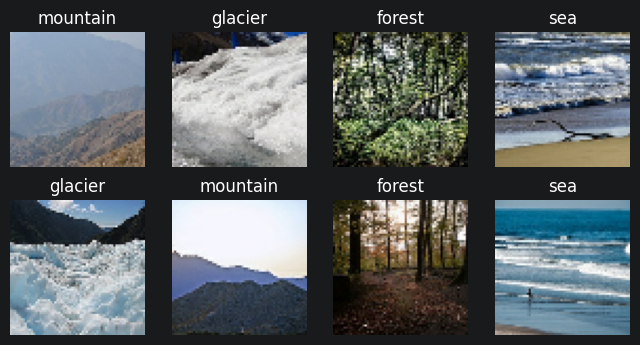

In [3]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that all splits have about an equal amount of each class.

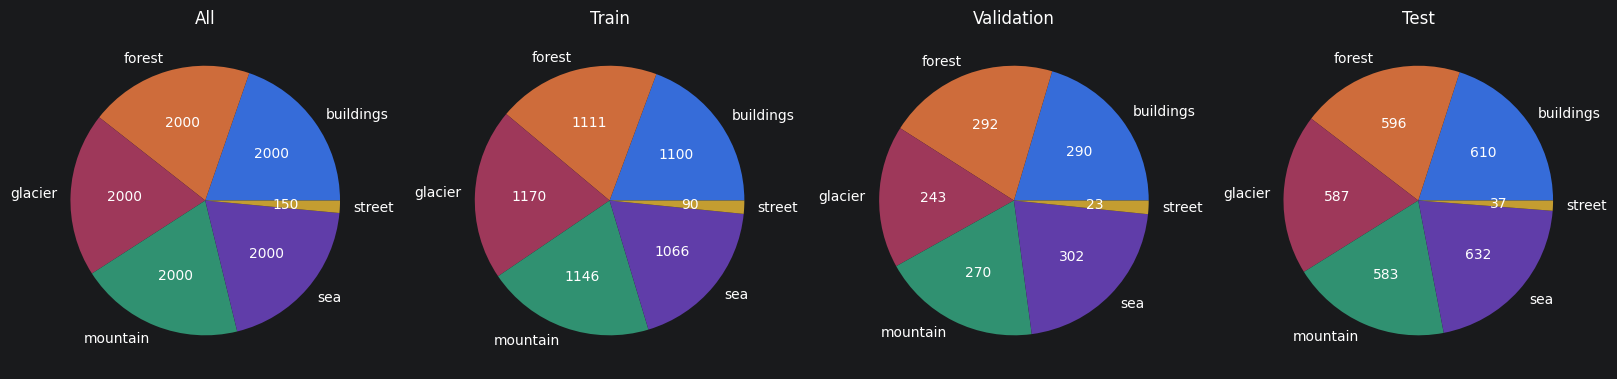

In [4]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

To improve the overfitting model we chose to add a dropout layer before the dense layer and add regularization for the last 2 convolutional as well as the dense layer. After some testing we found that not using regularization on the first two convolutional layers improves how easy it is to fine tune the model and therefore the performance.

The dropout layer before the dense layer is optimal for reducing noise going into the final layer.

The hyperparameters were chosen by the KerasTuner, which checked nearly 200 different combinations of the hyperparameter, which eventually lead to a dropout of `0.4` and a lamda of `0.0015`. This is not included in here, but run in a separate script.

Both these hyperparameters should help to get rid of the overfitting and achieve a better validation accuracy and loss, than the overfitting model.

In [5]:
def create_model():
    dropout = 0.4
    regularizer = regularizers.l2(0.0015)

    new_model = models.Sequential([
        layers.Input(shape=image_size + (3,)),
        layers.Rescaling(1./255),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", kernel_regularizer=regularizer),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation="relu", kernel_regularizer=regularizer),

        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(len(label_names), activation="softmax", kernel_regularizer=regularizer)
    ])
    new_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return new_model

model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,846 (530.65 KB)

 Trainable params: 135,846 (530.65 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we train the model for 30 epochs, as we did for the other two.

In [6]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4480 - loss: 1.3718 - val_accuracy: 0.5901 - val_loss: 1.1049
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5629 - loss: 1.1050 - val_accuracy: 0.5732 - val_loss: 1.1678
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6092 - loss: 1.0099 - val_accuracy: 0.6711 - val_loss: 0.9042
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6497 - loss: 0.9414 - val_accuracy: 0.7063 - val_loss: 0.8404
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6797 - loss: 0.8852 - val_accuracy: 0.7408 - val_loss: 0.7739
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7246 - loss: 0.8073 - val_accuracy: 0.7803 - val_loss: 0.7001
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7385 - loss: 0.7645 - val_accuracy: 0.7817 - val_loss: 0.6896
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7533 - loss: 0.7259 - val_accu

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if its more optimal then the previous models.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

### Confusion Matrix
We have 4 different confusion matrices plotted, On the y-scale we have th actual labes and on the x-scale is what the model predicted.

### Scores
The last three plots show us some important training metrics such as f1-score, precision and recall.

Validation accuracy: 0.8570422530174255
Validation Loss: 0.5700698494911194


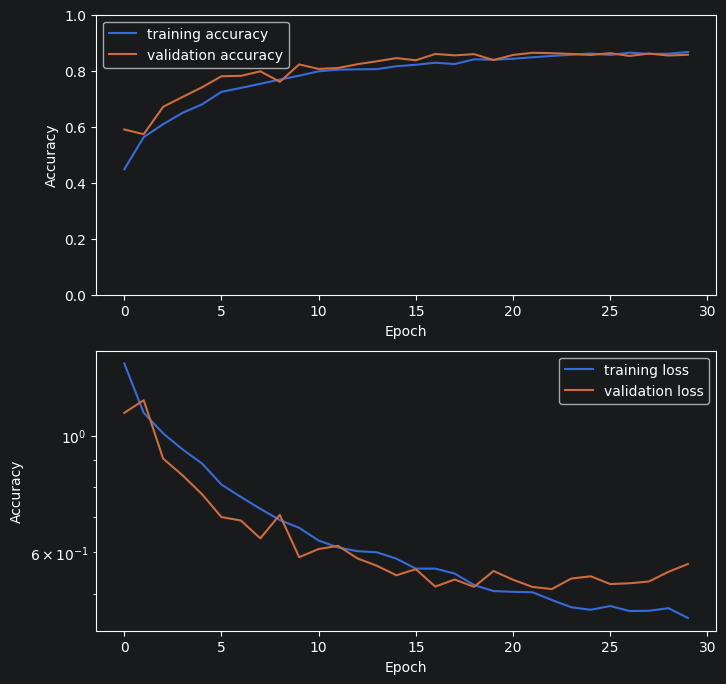

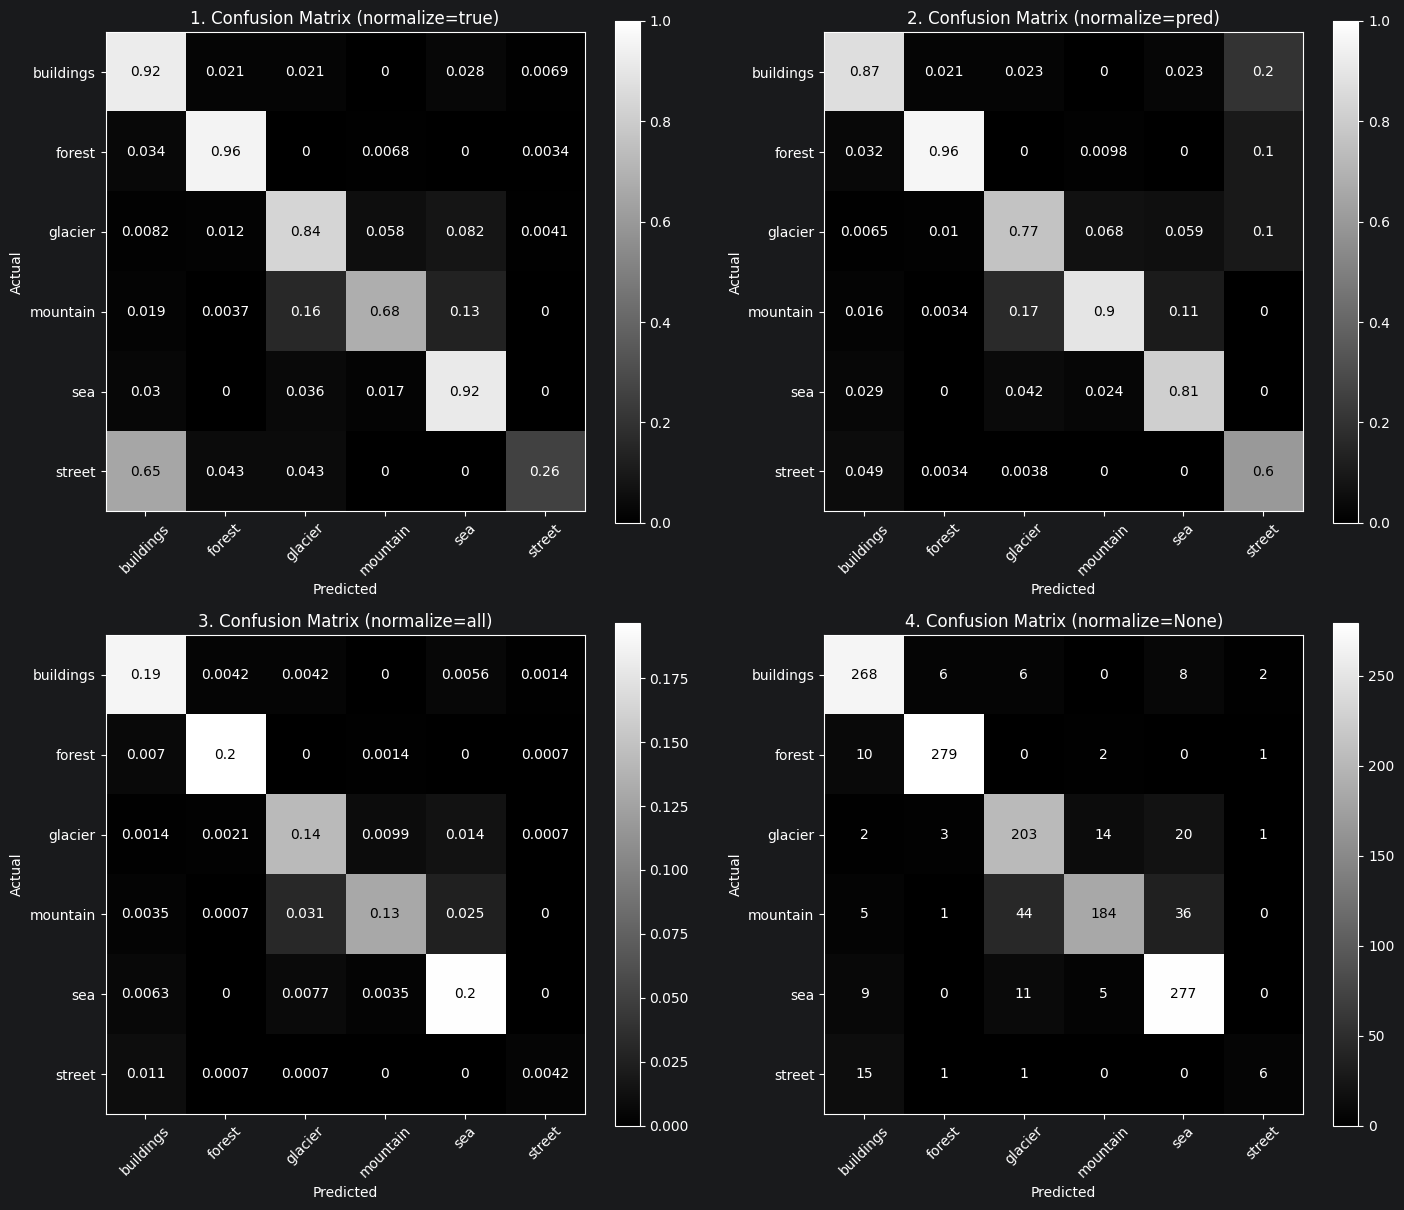

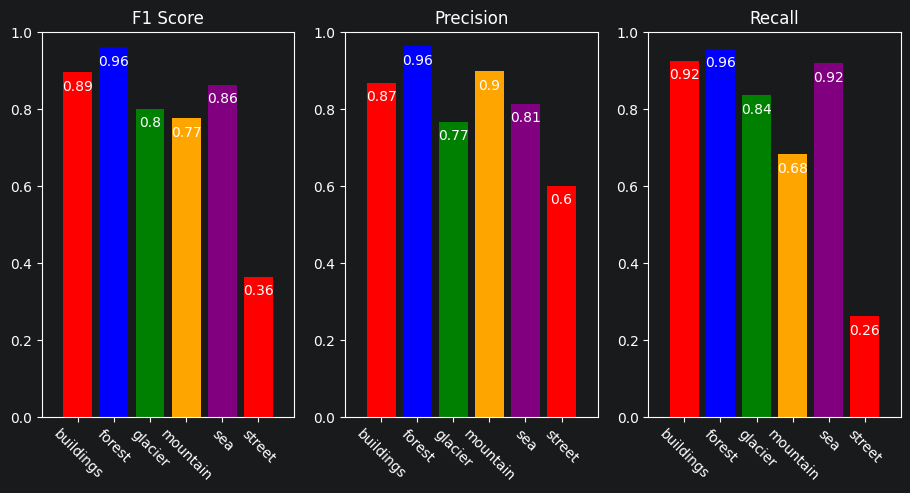

In [7]:
true, pred, pred_raw = calculate_predictions(model, validation_images.batch(batch_size))

print_accuracy_and_loss(model, validation_images.batch(batch_size))
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion of results
- Overall performance: The model has a training accuracy of about 0.875 and a validation accuracy of about 0.87. Our model performs similar on training and validation data which is great.
- Accuracy: Training accuracy and validation are being close and high. This means our model stopped learning random noise from the training data. The model is not overfitting anymore.
- Loss: Validation loss is also quite close to training loss, which is good. Our model has similar confidence when predicting validation data. Only in the last fe epochs the validation loss rises a bit, which has been expected.
- Confusion Matrix:
  1. The streets samples still often get predicted as building but has gotten better.
  2. Looking at street we see that most street predictions now actually also are streets, somthing that we didn't have in the models before. The model also struggles less with confusing glaciers and mountains for each other.
  3. Comparing it to the overfitting model we see general improvement across the board.
  4. We notice that matrix 3. is a bit misleading. Matrix 3 has 2 classes which look very good. But here we see that those 2 classes have some more data than the rest.
- Training metrics
    - F1 score: Here we can again see that the model handles the unbalance of the street class in our dataset way better than the models before. But you can still see the gap to the other classes.
    - Precision: The model now predicts street quit good, nearly as good as glacier.
    - Recall: Street still gets predicted less but in comparison to overfitting it is a huge improvement.

# Cross Validation

To make sure we did not only get lucky with our hyperparameters on the previous model we use cross validation with 5 folds. This will give us an average accuracy and loss for 5 different training splits.

In [8]:
cv_results = execute_cv(create_model, dataset=train_images.concatenate(validation_images), folds=5, epochs=30)

Fold 1 / 5
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4527 - loss: 1.3785 - val_accuracy: 0.4870 - val_loss: 1.2286
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5788 - loss: 1.0963 - val_accuracy: 0.5834 - val_loss: 1.0326
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6448 - loss: 0.9721 - val_accuracy: 0.6594 - val_loss: 0.9153
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6793 - loss: 0.8926 - val_accuracy: 0.7333 - val_loss: 0.7762
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6999 - loss: 0.8511 - val_accuracy: 0.7305 - val_loss: 0.7889
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7298 - loss: 0.7800 - val_accuracy: 0.7481 - val_loss: 0.7506
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7552 - loss: 0.7291 - val_accuracy: 0.7671 - val_loss: 0.7306
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7580 - loss: 0.7083

Now we want to see how they performed compared to each other. Therefore, we look at the mean and standard deviation of the validation accuracy and loss.

We see that all folds performed similar. We can safely say that the model and our chosen hyperparameters are generally good.

Mean	Std. dev.	Name
0.8322	0.0067		Accuracy
0.5753	0.0350		Loss


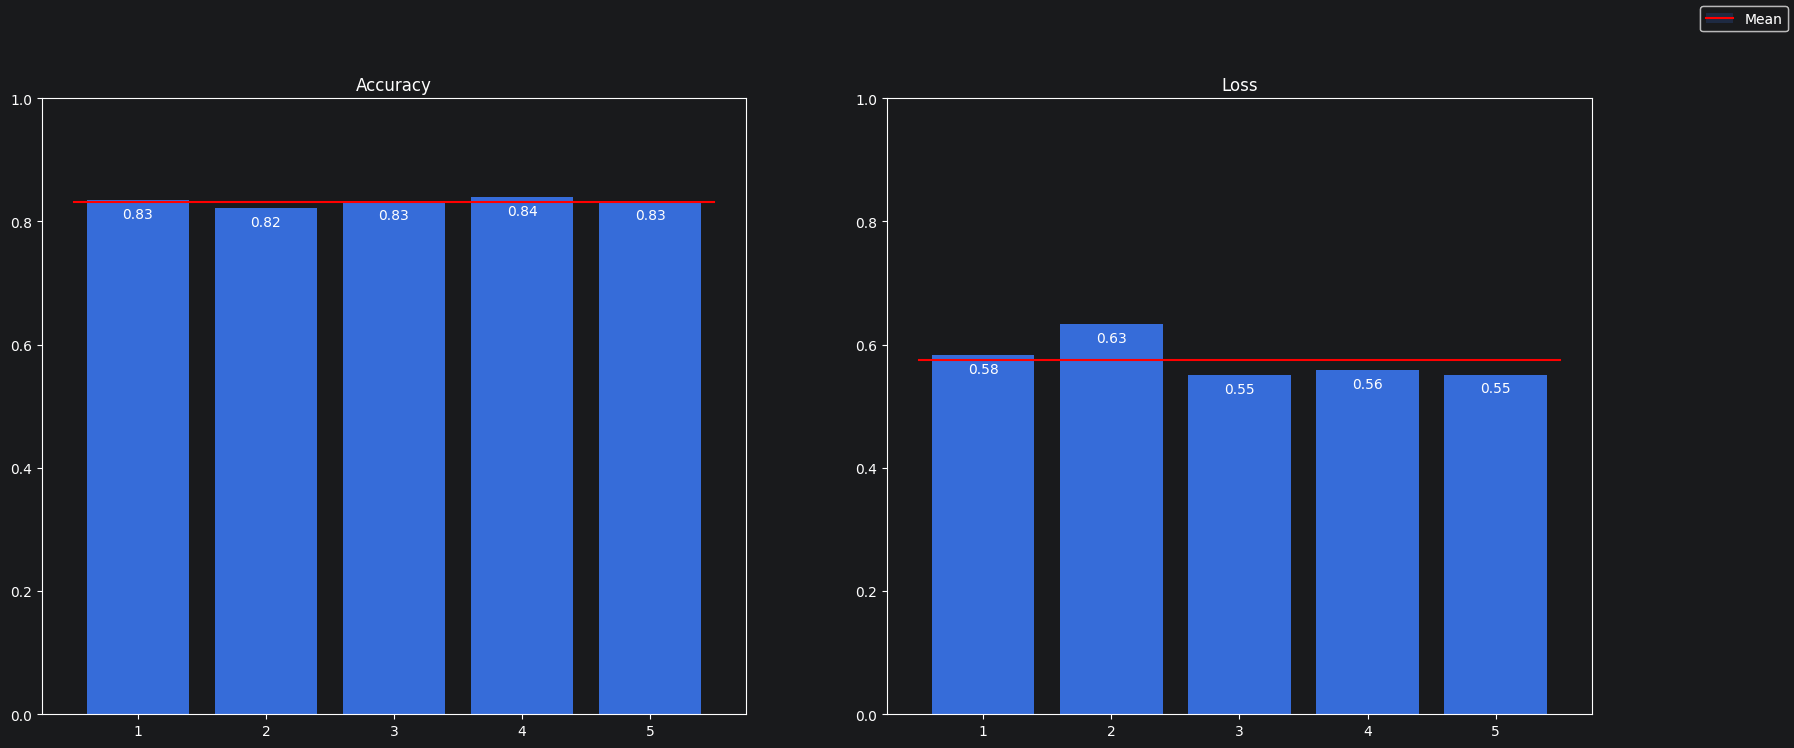

In [9]:
print("Mean\tStd. dev.\tName")
for name, values in cv_results.items():
    print(f"{mean(values):.4f}\t{stdev(values):.4f}\t\t{name}")

plot_cv_results(cv_results)

# Evaluating with the Test data

Since we only used the train and validation data until now, it is time to see, how good the model is on our unused test data.

To do this we use the trained model and predict the labels with the test data. This will tell us if our model is favoring the validation data or if the model can be applied for classifying any images of those classes.

And as we can see the mean accuracy and loss of k-folds are similar to the accuracy and loss of the predictions on the test data.


In [10]:
print_accuracy_and_loss(model, test_images.batch(batch_size))

Validation accuracy: 0.833825945854187
Validation Loss: 0.6484371423721313


# Conclusion

We have trained and evaluated three different models, an underfitting, an overfitting and an optimal. All models were not exactly performing very good, but a clear improvement can be seen.

The street class was very difficult to train, since it can easily be mistaken with a building and vice versa.
Therefore, we would recommend to increase the weight for this class in training or increase the image number.

## Side notes

We did use a few scripts not in the notebooks to make our life easier. We used a setup script and a tuner script to find the optimal hyperparameters. Several other scripts were used to test small changes, which did not make it into this notebooks.

Also we did initially use a completely different data set for rice, which performed very well. So well that we could not get it to overfit at all and to underfit it needed less than 500 trainable parameters. But we managed to get over 99% accuracy with less than 1000 parameters. That is why we switched to a new dataset in the end, which sadly did not perform as good, but at least did help us to show underfitting and overfitting.